In [41]:
!which python

/mnt/netapp2/Store_uni/home/ulc/co/rpj/projects/CP-HOSfing/venv/bin/python


In [42]:
import random
import numpy as np
import pandas as pd
import polars as pl
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from concurrent.futures import ThreadPoolExecutor

sns.set(color_codes=True)
%matplotlib inline 

In [43]:
seed = 42
random.seed(seed)
np.random.seed(seed)

### Functions Definitions

In [44]:
def my_show_df_shape(df):
    print("Number of examples/rows: {:,}".format(df.shape[0]))
    print("Number of features: {:,}".format(df.shape[1]))

In [45]:
def my_show_df_NaNs(df):
    nan_count = df.isna().sum()
    # nan_count = nan_count[nan_count > 0]
    nan_percentage = df.isna().mean() * 100
    # nan_percentage = nan_percentage[nan_percentage > 0]
    if nan_count.empty:
        print("No NaN values found in the dataset.")
    else:
        print("Number of examples/rows:", df.shape[0])
        print("Number of features:", df.shape[1])
        print("Features with NaNs:")
        for i in range(len(nan_count)):
            feature = nan_count.index[i]
            if nan_count[feature] > 0:
                print(f"{feature:<30} {nan_count[feature]:<10} {nan_percentage[feature]:<8.4f}%")
            else:
                print(f"{feature:<30} no NaNs")

### Dataset Load

In [46]:
import os

filenames = glob.glob(os.path.join(os.environ['STORE'], 'projects/CP-HOSfing/data/lastovicka2019/*.csv'))

print("Summary of CSV files found:")
total_files = len(filenames)
total_size = 0

for f in filenames:
    file_name = os.path.basename(f)
    try:
        size = os.path.getsize(f)
        with open(f, 'r', encoding='utf-8', errors='ignore') as file:
            num_lines = sum(1 for _ in file)
    except Exception as e:
        size = -1
        num_lines = -1
    total_size += size if size > 0 else 0
    print(f"File: {file_name:40}  Lines: {num_lines:8,}  Size: {size/1024/1024:8.2f} MB")

print(f"\nTotal number of files: {total_files}")
print(f"Total size: {total_size/1024/1024:.2f} MB")


Summary of CSV files found:
File: 2019-07-12-09_ground_truth.csv            Lines:  225,314  Size:    72.33 MB
File: 2019-07-12-10_ground_truth.csv            Lines:  260,213  Size:    83.83 MB
File: 2019-07-12-11_ground_truth.csv            Lines:  270,627  Size:    87.00 MB
File: 2019-07-15-16_ground_truth.csv            Lines:  278,174  Size:    82.08 MB
File: 2019-07-12-01_ground_truth.csv            Lines:   64,150  Size:    17.80 MB
File: 2019-07-12-00_ground_truth.csv            Lines:  113,140  Size:    33.88 MB
File: 2019-07-12-02_ground_truth.csv            Lines:   48,630  Size:    13.39 MB
File: 2019-07-12-03_ground_truth.csv            Lines:   35,733  Size:     9.60 MB
File: 2019-07-12-04_ground_truth.csv            Lines:   31,834  Size:     8.97 MB
File: 2019-07-12-05_ground_truth.csv            Lines:   36,968  Size:    10.35 MB
File: 2019-07-12-06_ground_truth.csv            Lines:   54,947  Size:    16.41 MB
File: 2019-07-12-07_ground_truth.csv            Lines:   97

In [47]:
# p = 0.1  # 10% of the lines - Around xxxx rows
p = 0.0025  # 0,25% of the lines - Around xxxx rows

# Polars lazy Bernoulli sampling via row-hash threshold (works without LazyFrame.sample)
# You can restrict columns by adding .select([...]) before hashing
_hash_mod = 1 << 64
_threshold = int(p * _hash_mod)

lazy = (
    pl.scan_csv(filenames, ignore_errors=True)
      .with_columns(rnd=pl.struct(pl.all()).hash(seed=seed))
      .filter(pl.col("rnd") < _threshold)
      .drop("rnd")
)

df = lazy.collect().to_pandas()

### Initial Exploration

In [18]:
df

,Date flow start,Date flow end,Src IPv4,sPort,Dst IPv4,dPort,SYN size,TCP win,TCP SYN TTL,TLS SNI,...,HTTP UA OS MAJ,HTTP UA OS MIN,HTTP UA OS BLD,SSH Client Version,SSH Client Application,SSH Client Encryption,SSH Client MAC,SSH Client Compression,Session ID,Ground Truth OS
0,2019-07-12 08:59:53.924,2019-07-12 08:59:54.309,151.27.200.157,53153.0,229.186.215.104,443.0,None,None,None,None,...,None,None,None,None,None,None,None,None,56056,Android
1,2019-07-12 08:57:37.017,2019-07-12 09:02:32.912,151.27.200.18,49154.0,121.54.153.66,443.0,None,None,None,None,...,None,None,None,None,None,None,None,None,81127,Windows
2,2019-07-12 09:01:58.742,2019-07-12 09:01:58.742,151.27.17.101,34962.0,116.58.197.59,123.0,None,None,None,None,...,None,None,None,None,None,None,None,None,68752,Android
3,2019-07-12 08:51:26.357,2019-07-12 08:55:06.385,151.27.74.187,48084.0,3.230.73.185,5222.0,60,65535,62,None,...,None,None,None,None,None,None,None,None,21819,Android
4,2019-07-12 09:00:28.316,2019-07-12 09:00:28.316,151.27.205.8,57346.0,236.7.157.212,7680.0,52,64240,126,None,...,None,None,None,None,None,None,None,None,96245,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47095,2019-07-16 23:54:00.149,2019-07-16 23:54:00.149,151.27.21.57,54456.0,32.190.238.48,443.0,52,64240,126,push.services.mozilla.com,...,None,None,None,None,None,None,None,None,104971,Windows
47096,2019-07-16 23:53:58.464,2019-07-16 23:53:59.648,151.27.17.179,51972.0,19.205.255.221,443.0,64,65535,62,valid.apple.com,...,None,None,None,None,None,None,None,None,110397,iOS
47097,2019-07-16 23:53:59.695,2019-07-16 23:53:59.712,151.27.205.121,46492.0,108.184.221.126,443.0,60,65535,62,ton.twimg.com,...,None,None,None,None,None,None,None,None,92738,iOS
47098,2019-07-16 23:54:15.861,2019-07-16 23:58:16.146,151.27.76.188,55559.0,179.22.75.185,443.0,60,65535,62,android.googleapis.com,...,None,None,None,None,None,None,None,None,8989,Android


In [19]:
my_show_df_shape(df)

Number of examples/rows: 47,100
Number of features: 29


In [20]:
print(df.info())  # Get information about the dataset (e.g., column names, data types)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47100 entries, 0 to 47099
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date flow start         47100 non-null  object 
 1   Date flow end           47100 non-null  object 
 2   Src IPv4                47100 non-null  object 
 3   sPort                   45920 non-null  float64
 4   Dst IPv4                47100 non-null  object 
 5   dPort                   45920 non-null  float64
 6   SYN size                33839 non-null  object 
 7   TCP win                 33839 non-null  object 
 8   TCP SYN TTL             33839 non-null  object 
 9   TLS SNI                 23907 non-null  object 
 10  TLS SNI length          24148 non-null  object 
 11  TLS Client Version      24133 non-null  object 
 12  Client Cipher Suites    24148 non-null  object 
 13  TLS Extension Types     24148 non-null  object 
 14  TLS Extension Lengths   24148 non-null

In [21]:
print(df.head())  # Display the first few rows of the dataset

           Date flow start            Date flow end        Src IPv4    sPort  \
0  2019-07-12 08:59:53.924  2019-07-12 08:59:54.309  151.27.200.157  53153.0   
1  2019-07-12 08:57:37.017  2019-07-12 09:02:32.912   151.27.200.18  49154.0   
2  2019-07-12 09:01:58.742  2019-07-12 09:01:58.742   151.27.17.101  34962.0   
3  2019-07-12 08:51:26.357  2019-07-12 08:55:06.385   151.27.74.187  48084.0   
4  2019-07-12 09:00:28.316  2019-07-12 09:00:28.316    151.27.205.8  57346.0   

          Dst IPv4   dPort SYN size TCP win TCP SYN TTL TLS SNI  ...  \
0  229.186.215.104   443.0     None    None        None    None  ...   
1    121.54.153.66   443.0     None    None        None    None  ...   
2    116.58.197.59   123.0     None    None        None    None  ...   
3     3.230.73.185  5222.0       60   65535          62    None  ...   
4    236.7.157.212  7680.0       52   64240         126    None  ...   

  HTTP UA OS MAJ HTTP UA OS MIN HTTP UA OS BLD SSH Client Version  \
0           None 

In [22]:
columns_list = df.columns.tolist()
print(columns_list)  # Get the list of columns in the dataset

['Date flow start', 'Date flow end', 'Src IPv4', 'sPort', 'Dst IPv4', 'dPort', 'SYN size', 'TCP win', 'TCP SYN TTL', 'TLS SNI', 'TLS SNI length', 'TLS Client Version', 'Client Cipher Suites', 'TLS Extension Types', 'TLS Extension Lengths', 'TLS Elliptic Curves', 'TLS EC Point Formats', 'HTTP Host', 'HTTP UA OS', 'HTTP UA OS MAJ', 'HTTP UA OS MIN', 'HTTP UA OS BLD', 'SSH Client Version', 'SSH Client Application', 'SSH Client Encryption', 'SSH Client MAC', 'SSH Client Compression', 'Session ID', 'Ground Truth OS']


In [23]:
column_names_by_dtype = {str(dtype): columns.to_list() for dtype, columns in df.columns.groupby(df.dtypes).items()}
for dtype, columns in column_names_by_dtype.items():
    print(f"{dtype} ({len(columns)})")
    print(columns)
    print()

int64 (1)
['Session ID']

float64 (2)
['sPort', 'dPort']

object (26)
['Date flow start', 'Date flow end', 'Src IPv4', 'Dst IPv4', 'SYN size', 'TCP win', 'TCP SYN TTL', 'TLS SNI', 'TLS SNI length', 'TLS Client Version', 'Client Cipher Suites', 'TLS Extension Types', 'TLS Extension Lengths', 'TLS Elliptic Curves', 'TLS EC Point Formats', 'HTTP Host', 'HTTP UA OS', 'HTTP UA OS MAJ', 'HTTP UA OS MIN', 'HTTP UA OS BLD', 'SSH Client Version', 'SSH Client Application', 'SSH Client Encryption', 'SSH Client MAC', 'SSH Client Compression', 'Ground Truth OS']



In [24]:
# Count the number of NaN values in the dataframe
nan_count = df.isna().sum().sum()

# Count the number of duplicated values in the dataframe
duplicated_count = df.duplicated().sum()

# Print the results
print("Number of NaN values:", nan_count)
print("Number of duplicated values:", duplicated_count)

Number of NaN values: 669593
Number of duplicated values: 0


In [25]:
my_show_df_NaNs(df)

Number of examples/rows: 47100
Number of features: 29
Features with NaNs:
Date flow start                no NaNs
Date flow end                  no NaNs
Src IPv4                       no NaNs
sPort                          1180       2.5053  %
Dst IPv4                       no NaNs
dPort                          1180       2.5053  %
SYN size                       13261      28.1550 %
TCP win                        13261      28.1550 %
TCP SYN TTL                    13261      28.1550 %
TLS SNI                        23193      49.2420 %
TLS SNI length                 22952      48.7304 %
TLS Client Version             22967      48.7622 %
Client Cipher Suites           22952      48.7304 %
TLS Extension Types            22952      48.7304 %
TLS Extension Lengths          22952      48.7304 %
TLS Elliptic Curves            22952      48.7304 %
TLS EC Point Formats           22952      48.7304 %
HTTP Host                      44793      95.1019 %
HTTP UA OS                     40830      

In [26]:
df.describe()

,sPort,dPort,Session ID
count,45920.000000,45920.000000,47100.000000
mean,48277.220862,5376.841964,60189.995053
std,14978.388815,13528.235402,34071.959615
min,0.000000,0.000000,41.000000
25%,43740.250000,443.000000,30549.000000
50%,52079.000000,443.000000,60325.000000
75%,58033.000000,443.000000,90152.000000
max,65533.000000,65530.000000,115851.000000


In [27]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47100 entries, 0 to 47099
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date flow start         47100 non-null  object 
 1   Date flow end           47100 non-null  object 
 2   Src IPv4                47100 non-null  object 
 3   sPort                   45920 non-null  float64
 4   Dst IPv4                47100 non-null  object 
 5   dPort                   45920 non-null  float64
 6   SYN size                33839 non-null  object 
 7   TCP win                 33839 non-null  object 
 8   TCP SYN TTL             33839 non-null  object 
 9   TLS SNI                 23907 non-null  object 
 10  TLS SNI length          24148 non-null  object 
 11  TLS Client Version      24133 non-null  object 
 12  Client Cipher Suites    24148 non-null  object 
 13  TLS Extension Types     24148 non-null  object 
 14  TLS Extension Lengths   24148 non-null

#### Target Classes

In [28]:
target = 'Ground Truth OS'

In [29]:
df[target].value_counts()

Ground Truth OS
Windows          18788
Android          17823
iOS               6689
Mac OS            3697
Windows Phone      103
Name: count, dtype: int64

array([[<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>]],
      dtype=object)

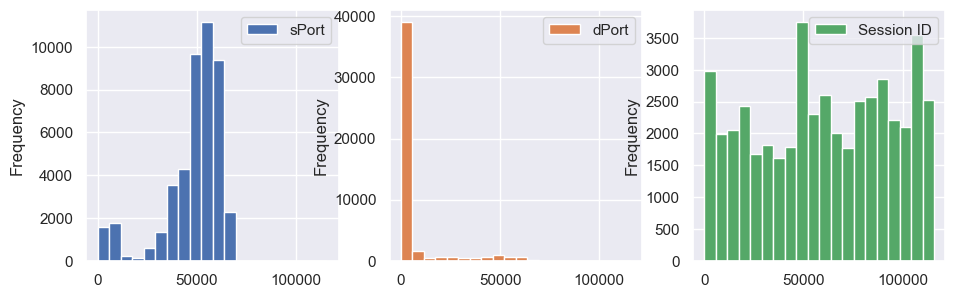

In [30]:
df.plot.hist(subplots=True, layout=(4, 4), figsize=(15, 15), bins=20)

#### Histogram

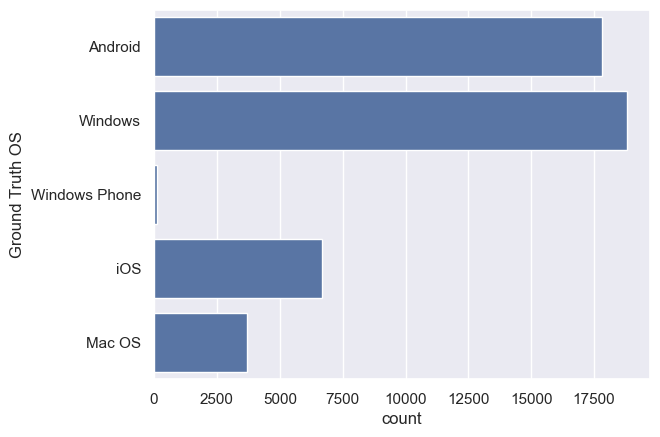

In [31]:
plt.xticks(rotation=0)
sns.countplot(y=target, data=df)
plt.show()

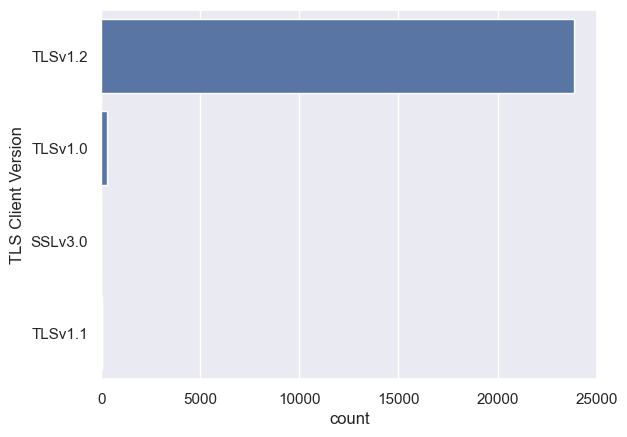

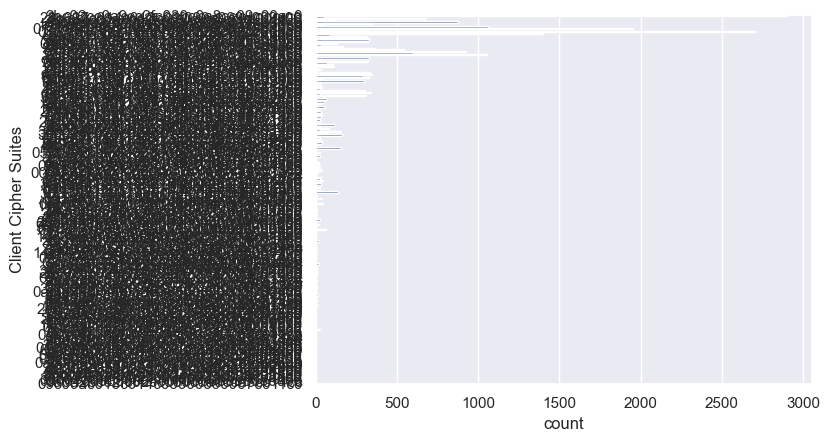

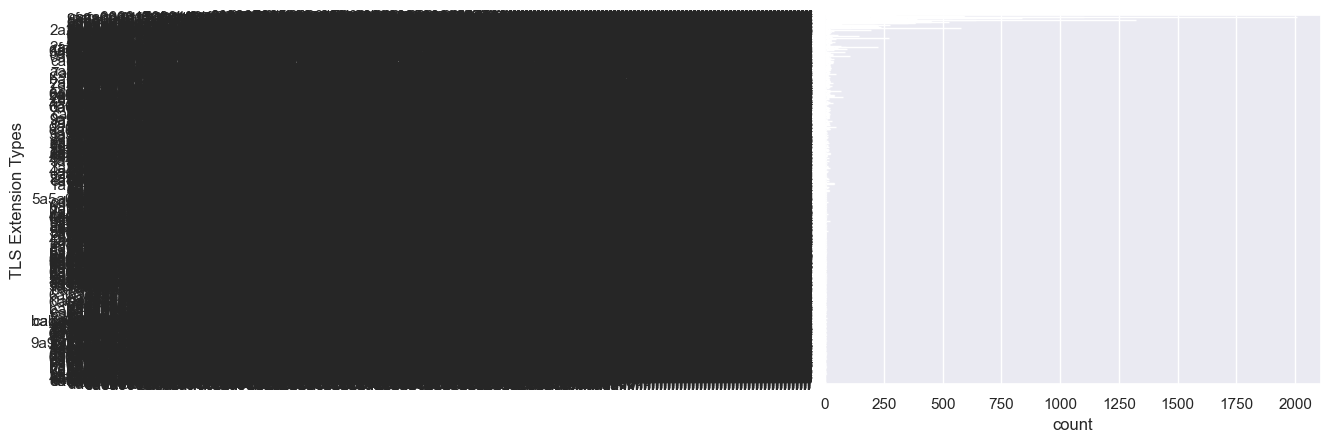

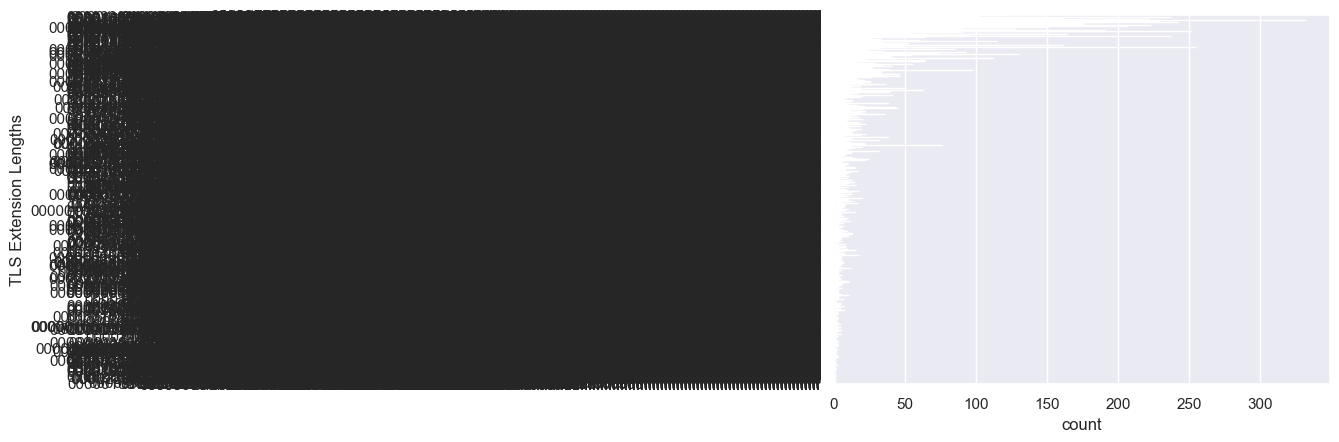

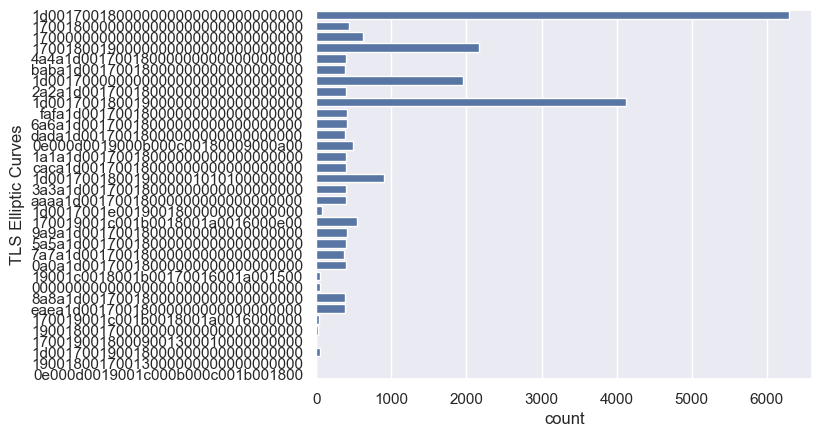

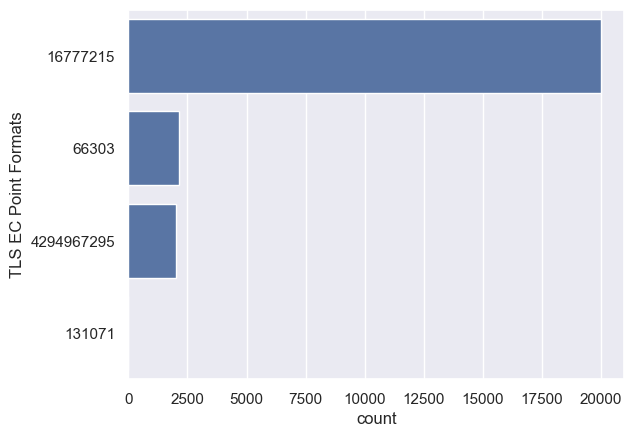

In [32]:
CATEGORICAL_FEATURES = [
    "TLS Client Version", "Client Cipher Suites", 
    "TLS Extension Types", "TLS Extension Lengths",
    "TLS Elliptic Curves", "TLS EC Point Formats" 
]

for feature in CATEGORICAL_FEATURES:
    plt.xticks(rotation=0)
    sns.countplot(y=feature, data=df)
    plt.show()

In [33]:
# df_hist = df['HTTP_Host_OS'] + " " + df['HTTP_Host_OS_Major_Version'].astype(str)
# top_10_values = df_hist.value_counts().head(15)
# df_hist = df_hist[df_hist.isin(top_10_values.index)]
# sns.countplot(data=df_hist)

In [34]:
# df_hist = df['HTTP_Host_OS'] + " " + df['HTTP_Host_OS_Major_Version'].astype(str) + " " + df['HTTP_Host_OS_Minor_Version'].astype(str)
# top_10_values = df_hist.value_counts().head(15)
# df_hist = df_hist[df_hist.isin(top_10_values.index)]
# sns.countplot(data=df_hist)

#### Correlation Heatmaps

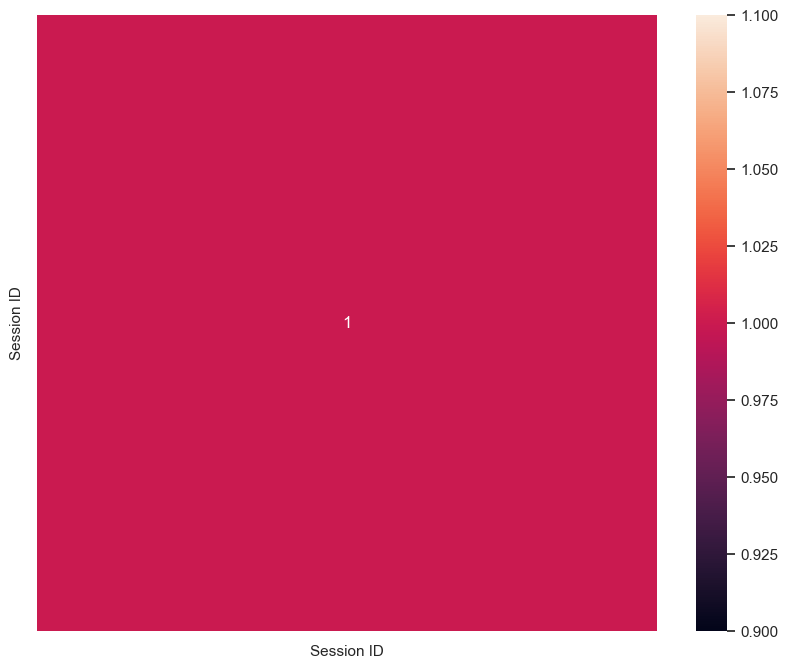

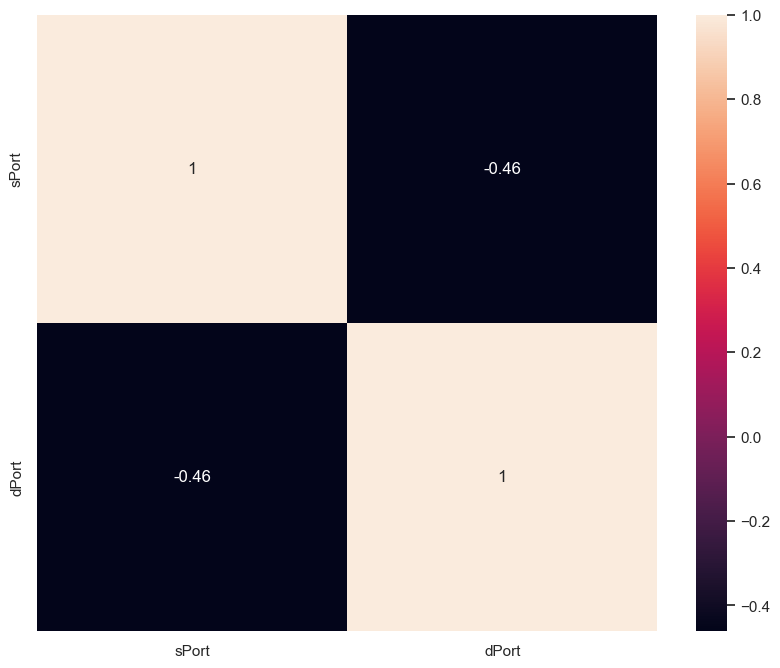

In [35]:
for dtype, columns in column_names_by_dtype.items():
    if dtype in ['int64', 'float64']:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[columns].corr(), annot=True)
        plt.show()

array([[<Axes: title={'center': 'Session ID'}, xlabel='[Ground Truth OS]'>,
        <Axes: title={'center': 'dPort'}, xlabel='[Ground Truth OS]'>],
       [<Axes: title={'center': 'sPort'}, xlabel='[Ground Truth OS]'>,
        <Axes: >]], dtype=object)

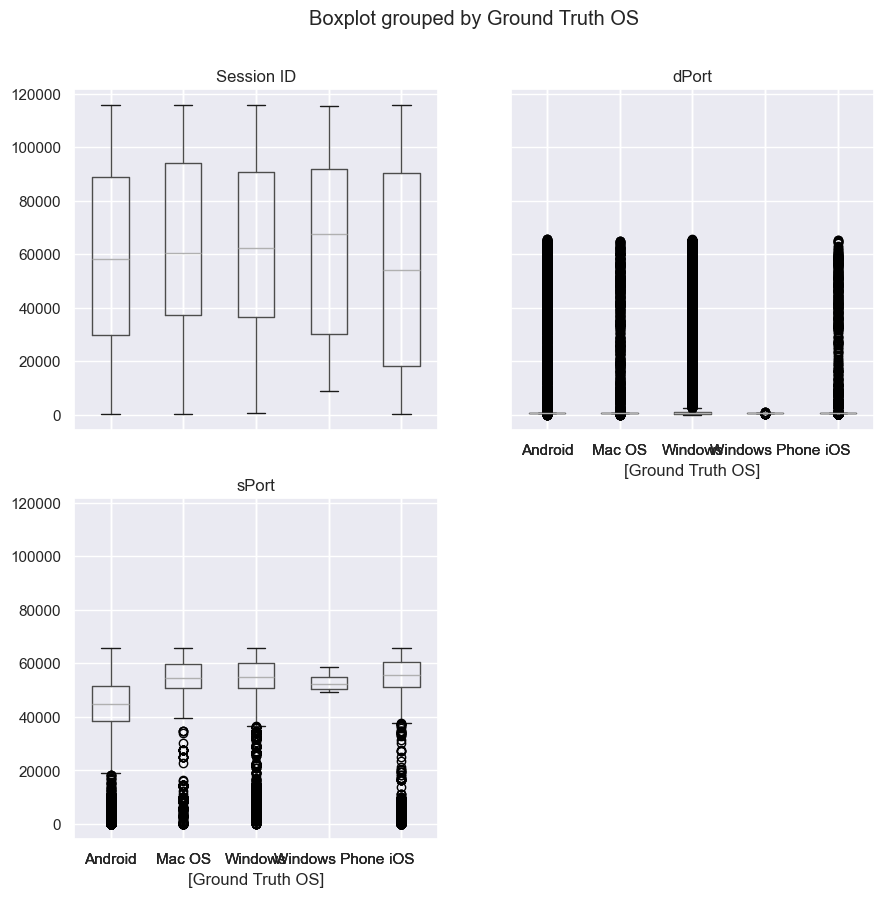

In [36]:
df.boxplot(by=target,figsize=(10,10))

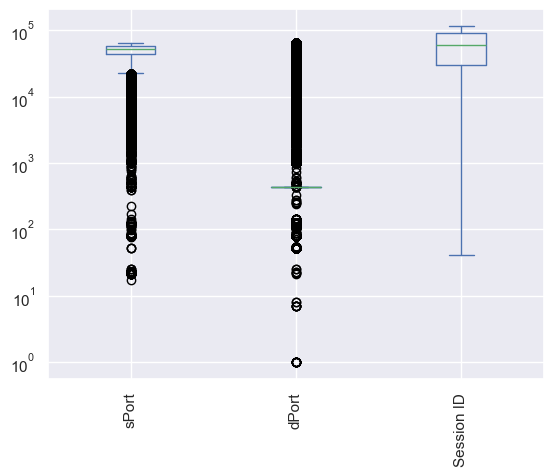

In [37]:
# Plot the figure
df.plot(kind='box', logy=True)

# Rotate the x-axis labels
plt.xticks(rotation=90)

# Show the figure
plt.show()

array([[<Axes: title={'center': 'sPort'}>,
        <Axes: title={'center': 'dPort'}>],
       [<Axes: title={'center': 'Session ID'}>, <Axes: >]], dtype=object)

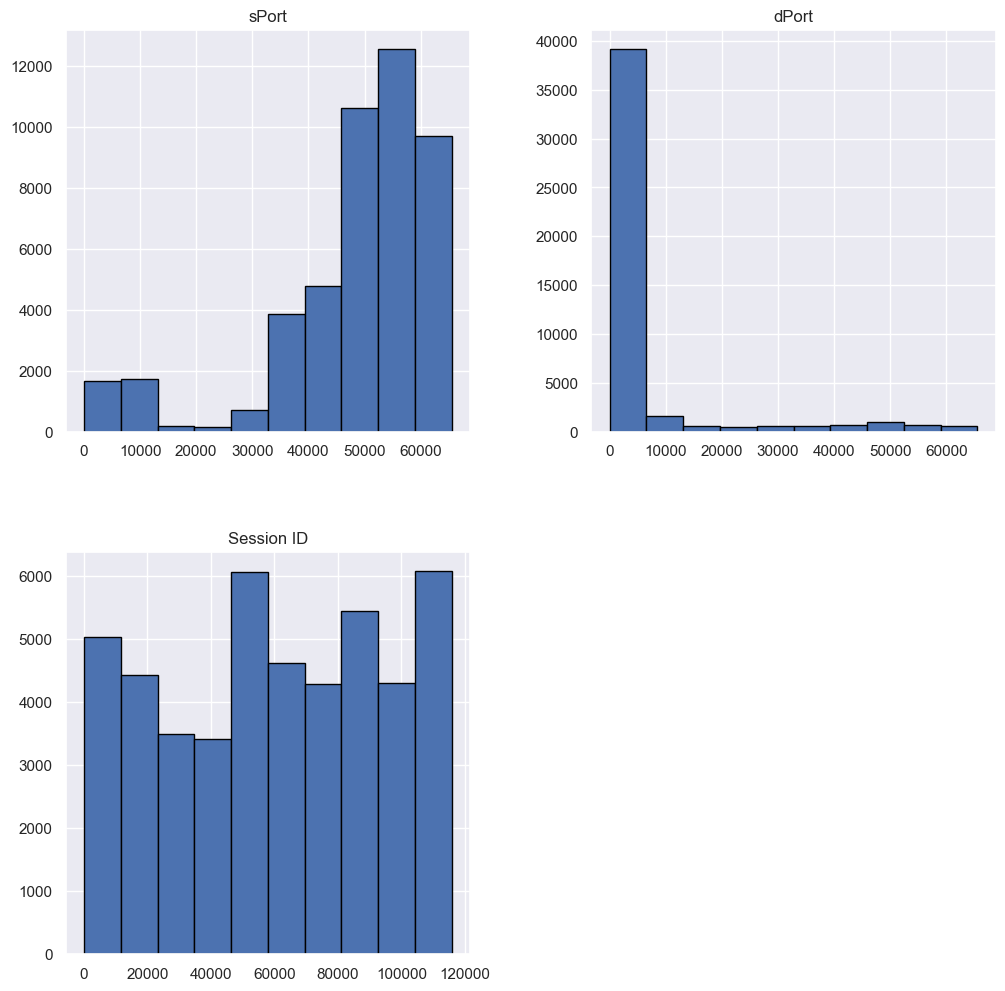

In [38]:
df.hist(edgecolor='black', figsize=(12, 12))

array([[<Axes: title={'center': 'sPort'}>,
        <Axes: title={'center': 'dPort'}>],
       [<Axes: title={'center': 'Session ID'}>, <Axes: >]], dtype=object)

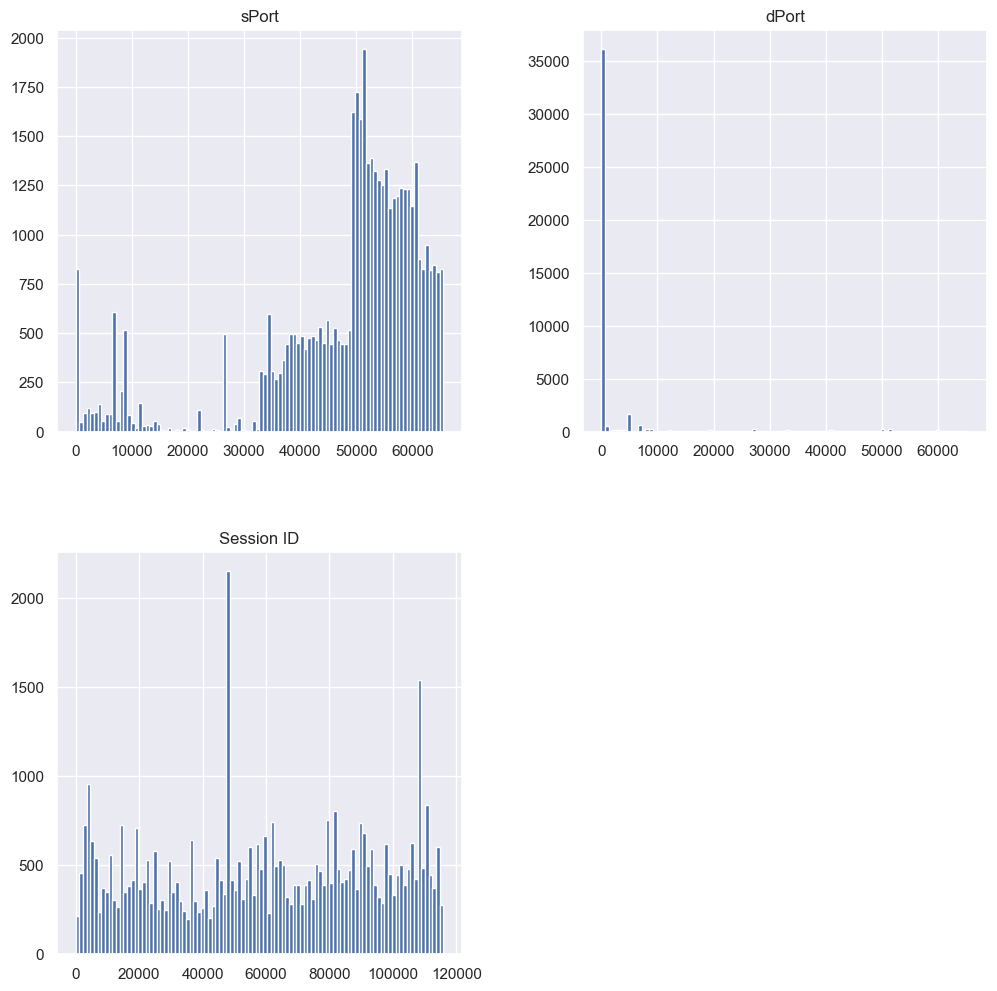

In [39]:
df.hist(bins=100, figsize=(12, 12))

In [40]:
df_toplot=df.drop(targets,axis=1)
scatter_matrix(df_toplot,figsize=(10,10))
plt.show()

NameError: name 'targets' is not defined

In [ ]:
sns.pairplot(df, hue=target)

### Preprocessing

#### Removing NaN

In [ ]:
my_show_df_NaNs(df)

In [ ]:
df.dropna(subset=target, inplace=True)

In [ ]:
my_show_df_NaNs(df)

In [ ]:
df['HTTP_Host_OS_Major_Version'] = df['HTTP_Host_OS_Major_Version'].fillna(0)

In [ ]:
my_show_df_NaNs(df)

#### Removing Features

In [ ]:
df.drop(['HTTP_Host_OS_Minor_Version', 'HTTP_hostname'], axis=1, inplace=True)

In [ ]:
my_show_df_NaNs(df)

In [ ]:
df['OS_target'] = df['HTTP_Host_OS'] + " " + df['HTTP_Host_OS_Major_Version'].astype(str)

In [ ]:
my_show_df_shape(df)

In [ ]:
for column in ['OS_target', 'HTTP_Host_OS', 'HTTP_Host_OS_Major_Version']:
    plt.xticks(rotation=0)
    top = 15
    top_values = df[column].value_counts().head(top)
    sns.countplot(y=column, data=df[df[column].isin(top_values.index)])
    plt.show()

In [ ]:
df

### Split